Question 1 Projection of a 3D Point

In [19]:
import numpy as np

# ==========================================
# 1. CAMERA PARAMETERS & INITIALIZATION
# ==========================================
# Camera intrinsic matrix K
f = 480
cx, cy = 320, 270
K = np.array([
    [f, 0, cx],
    [0, f, cy],
    [0, 0, 1]
])

# Extrinsic parameters (Global to Camera transformation)
R_G_C = np.array([
    [0.5363, -0.8440, 0],
    [0.8440, 0.5363, 0],
    [0, 0, 1]
])
t_C_to_G_global = np.array([[-451.2459], [257.0322], [400]])

# Target 3D point in Global Frame
X_G = np.array([[350], [-250], [-35]])

# Ground truth observed image coordinates
obs_u, obs_v = 241.5, 169.0

# ==========================================
# 2. COMPUTATION
# ==========================================
# (a) Calculate Camera Projection Matrix P
# Transform translation vector from world-centric to camera-centric frame
t_camera_frame = -R_G_C @ t_C_to_G_global
Rt_matrix = np.hstack((R_G_C, t_camera_frame))
P = K @ Rt_matrix

print("--- Question 1(a) ---")
print("Camera Projection Matrix P:")
print(np.round(P, 4))

# (b) Project the 3D point into Homogeneous 2D Space
X_G_homogeneous = np.vstack((X_G, [[1]]))
x_img_homogeneous = P @ X_G_homogeneous

# Convert from homogeneous to Euclidean 2D pixel coordinates by dividing by Z
Z_depth = x_img_homogeneous[2, 0]
u_projected = x_img_homogeneous[0, 0] / Z_depth
v_projected = x_img_homogeneous[1, 0] / Z_depth

print("\n--- Question 1(b) ---")
print(f"Projected Image Coordinates (u, v): ({u_projected:.4f}, {v_projected:.4f})")
print(f"Computed Depth (Z): {Z_depth:.4f}")
print("Verification Note: Since Z is negative, the 3D point is physically behind the camera viewpoint.")

# (c) Calculate Euclidean Re-projection Error
reprojection_error = np.sqrt((u_projected - obs_u)**2 + (v_projected - obs_v)**2)

print("\n--- Question 1(c) ---")
print(f"Re-projection Error: {reprojection_error:.4f} pixels")

--- Question 1(a) ---
Camera Projection Matrix P:
[[ 2.57424000e+02 -4.05120000e+02  3.20000000e+02  9.22904094e+04]
 [ 4.05120000e+02  2.57424000e+02  2.70000000e+02  8.64248200e+03]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00 -4.00000000e+02]]

--- Question 1(b) ---
Projected Image Coordinates (u, v): (-626.3651, -176.1574)
Computed Depth (Z): -435.0000
Verification Note: Since Z is negative, the 3D point is physically behind the camera viewpoint.

--- Question 1(c) ---
Re-projection Error: 933.9826 pixels


Question 2 Calibrate Camera Using ChArUco Pattern

Using OpenCV version: 4.13.0
Found 29 calibration snapshots. Extracting features...


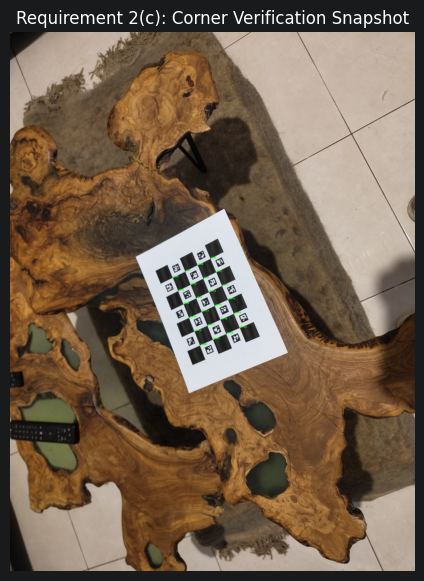

Computing optimization parameters...

--- Question 2(d): Calibration Results ---
Camera Intrinsic Matrix (K):
[[3.41128e+03 0.00000e+00 1.42794e+03]
 [0.00000e+00 3.34367e+03 1.23631e+03]
 [0.00000e+00 0.00000e+00 1.00000e+00]]

Extracted Focal Length Parameters: fx = 3411.28 pixels, fy = 3343.67 pixels
Extracted Center Principal Point: cx = 1427.94 pixels, cy = 1236.31 pixels


In [20]:
import cv2
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# ==========================================
# CONFIGURATION BLOCK
# ==========================================
CALIBRATION_DIR = "calibration_images"
CHARUCO_SQUARES_X = 5
CHARUCO_SQUARES_Y = 7

# Ensure you measure your physical printed pattern with a ruler!
SQUARE_METERS = 0.040  # Example: 40 millimeters
MARKER_METERS = 0.020  # Example: 20 millimeters

def run_charuco_calibration(data_directory):
    print(f"Using OpenCV version: {cv2.__version__}")

    # 1. Define the ArUco dictionary and ChArUco board
    dictionary = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_5X5_100)
    board = cv2.aruco.CharucoBoard(
        (CHARUCO_SQUARES_X, CHARUCO_SQUARES_Y),
        SQUARE_METERS,
        MARKER_METERS,
        dictionary
    )

    # Crucial for reading the standard GitHub ChArUco pattern in newer OpenCV versions
    try:
        board.setLegacyPattern(True)
    except AttributeError:
        pass

    # 2. Check OpenCV version API to avoid the AttributeError
    is_cv2_modern = hasattr(cv2.aruco, 'CharucoDetector')
    if is_cv2_modern:
        charuco_detector = cv2.aruco.CharucoDetector(board)
    else:
        detector_params = cv2.aruco.DetectorParameters_create()

    all_corners = []
    all_ids = []
    frame_dimensions = None
    sample_render = None

    # Read files safely using pathlib
    dir_path = Path(data_directory)
    valid_extensions = {'.jpg', '.jpeg', '.png'}

    # Try the specific folder first
    image_files = [f for f in dir_path.iterdir() if f.suffix.lower() in valid_extensions] if dir_path.exists() else []

    # Fallback: If folder is empty, scan the root directory for uploaded jpegs (like 1000093189.jpg)
    if not image_files:
        print(f"No images found in '{data_directory}/'. Scanning root directory for standard JPEGs...")
        image_files = [f for f in Path('.').iterdir() if f.suffix.lower() in valid_extensions]

    if not image_files:
        print("Error: No images found. Please check your image paths.")
        return None, None

    print(f"Found {len(image_files)} calibration snapshots. Extracting features...")

    for file in image_files:
        frame = cv2.imread(str(file))
        if frame is None:
            continue

        gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        if frame_dimensions is None:
            frame_dimensions = gray_frame.shape[::-1]

        # Step 1: Detect ChArUco corners depending on OpenCV version
        if is_cv2_modern:
            # The NEW OpenCV 4.7+ API
            charuco_corners, charuco_ids, marker_corners, marker_ids = charuco_detector.detectBoard(gray_frame)
        else:
            # The OLD API
            marker_corners, marker_ids, _ = cv2.aruco.detectMarkers(gray_frame, dictionary, parameters=detector_params)
            if marker_ids is not None and len(marker_ids) > 0:
                ret, charuco_corners, charuco_ids = cv2.aruco.interpolateCornersCharuco(marker_corners, marker_ids, gray_frame, board)
            else:
                charuco_corners, charuco_ids = None, None

        # Step 2: Accumulate valid corners
        if charuco_corners is not None and charuco_ids is not None and len(charuco_corners) > 3:
            all_corners.append(charuco_corners)
            all_ids.append(charuco_ids)

            if sample_render is None:
                sample_render = frame.copy()
                cv2.aruco.drawDetectedCornersCharuco(sample_render, charuco_corners, charuco_ids, (0, 255, 0))
                sample_render = cv2.cvtColor(sample_render, cv2.COLOR_BGR2RGB)

    # Display the verification image inline (Requirement 2c)
    if sample_render is not None:
        plt.figure(figsize=(9, 7))
        plt.imshow(sample_render)
        plt.title("Requirement 2(c): Corner Verification Snapshot")
        plt.axis('off')
        plt.show()
    else:
        print("Error: ChArUco pattern could not be recognized. Ensure lighting is clear and checking boards match.")
        return None, None

    # Step 3: Run final optimization to solve for Intrinsics Matrix K
    print("Computing optimization parameters...")
    try:
        # Standard calibration method
        success, K_matrix, distortion_coefficients, _, _ = cv2.aruco.calibrateCameraCharuco(
            charucoCorners=all_corners,
            charucoIds=all_ids,
            board=board,
            imageSize=frame_dimensions,
            cameraMatrix=None,
            distCoeffs=None
        )
    except AttributeError:
        # Fallback for OpenCV 4.9.0+ where calibrateCameraCharuco was removed
        obj_points = []
        img_points = []
        for corners, ids in zip(all_corners, all_ids):
            objp, imgp = board.matchImagePoints(corners, ids)
            if objp is not None and len(objp) > 3:
                obj_points.append(objp)
                img_points.append(imgp)

        success, K_matrix, distortion_coefficients, _, _ = cv2.calibrateCamera(
            obj_points, img_points, frame_dimensions, None, None
        )

    print("\n--- Question 2(d): Calibration Results ---")
    print("Camera Intrinsic Matrix (K):")
    print(np.round(K_matrix, 2))
    print(f"\nExtracted Focal Length Parameters: fx = {K_matrix[0,0]:.2f} pixels, fy = {K_matrix[1,1]:.2f} pixels")
    print(f"Extracted Center Principal Point: cx = {K_matrix[0,2]:.2f} pixels, cy = {K_matrix[1,2]:.2f} pixels")

    return K_matrix, distortion_coefficients

# To run calibration:
K, dist = run_charuco_calibration(CALIBRATION_DIR)

Question 3
Image Feature Extraction and Matching

--- Question 3(b) ---
Representative Keypoint Metric -> Pixel Scale Size: 3.38
Representative Keypoint Metric -> Dominant Angular Orientation: 49.04°

--- Question 3(c) ---
Total computed features evaluated: 2550
Distinct Inlier matches passing test: 203
Rejected Outlier matches failing test: 2347


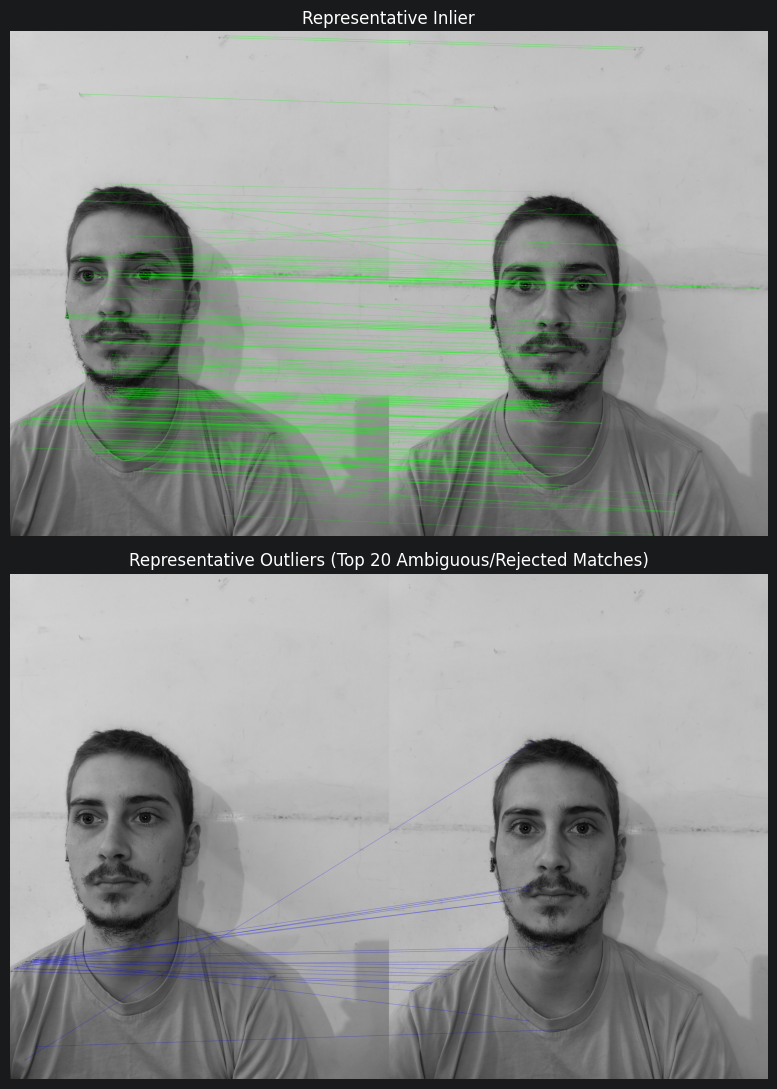

In [21]:
import cv2
import matplotlib.pyplot as plt

def compute_sift_correspondences(img1_path, img2_path):
    """
    Extracts SIFT features from two viewpoints and isolates regular inliers
    versus outliers using Lowe's ratio distance processing.
    """
    # Read incoming source files in grayscale mode
    image_a = cv2.imread(img1_path, cv2.IMREAD_GRAYSCALE)
    image_b = cv2.imread(img2_path, cv2.IMREAD_GRAYSCALE)

    if image_a is None or image_b is None:
        print("Missing assignment files. Please verify paths.")
        return

    # 1. Initialize SIFT Detector and compute descriptors
    sift_engine = cv2.SIFT_create()
    keypoints_a, descriptors_a = sift_engine.detectAndCompute(image_a, None)
    keypoints_b, descriptors_b = sift_engine.detectAndCompute(image_b, None)

    # Print out spatial specs for a single representative feature (Requirement 3b)
    if keypoints_a:
        example_kp = keypoints_a[0]
        print("--- Question 3(b) ---")
        print(f"Representative Keypoint Metric -> Pixel Scale Size: {example_kp.size:.2f}")
        print(f"Representative Keypoint Metric -> Dominant Angular Orientation: {example_kp.angle:.2f}°\n")

    # 2. Run raw Brute-Force matching with k=2 nearest entries
    matcher = cv2.BFMatcher()
    raw_knn_matches = matcher.knnMatch(descriptors_a, descriptors_b, k=2)

    # 3. Apply Lowe's Ratio Test to sort inliers from outliers
    inlier_matches = []
    outlier_matches = []

    for first_match, second_match in raw_knn_matches:
        if first_match.distance < 0.75 * second_match.distance:
            inlier_matches.append([first_match])
        else:
            outlier_matches.append([first_match])

    print("--- Question 3(c) ---")
    print(f"Total computed features evaluated: {len(raw_knn_matches)}")
    print(f"Distinct Inlier matches passing test: {len(inlier_matches)}")
    print(f"Rejected Outlier matches failing test: {len(outlier_matches)}")

    # 4. Generate Subplot Visualizations for Report Submission
    fig, axes = plt.subplots(2, 1, figsize=(14, 11))

    # Top Panel: Clean Green Lines for True Structural Inliers
    inlier_render = cv2.drawMatchesKnn(
        image_a, keypoints_a, image_b, keypoints_b, inlier_matches, None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS, matchColor=(0, 255, 0)
    )
    axes[0].imshow(cv2.cvtColor(inlier_render, cv2.COLOR_BGR2RGB))
    axes[0].set_title("Representative Inlier")
    axes[0].axis('off')

    # Bottom Panel: Crimson Lines indicating rejected Outlier matches
    outlier_render = cv2.drawMatchesKnn(
        image_a, keypoints_a, image_b, keypoints_b, outlier_matches[:20], None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS, matchColor=(255, 0, 0)
    )
    axes[1].imshow(cv2.cvtColor(outlier_render, cv2.COLOR_BGR2RGB))
    axes[1].set_title("Representative Outliers (Top 20 Ambiguous/Rejected Matches)")
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

# To execute feature pipeline:
compute_sift_correspondences("images/image11.jpg", "images/image12.jpg")